<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_position_gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D7_POSITION_GRADIENT — Radial Ring + Petal Address Map

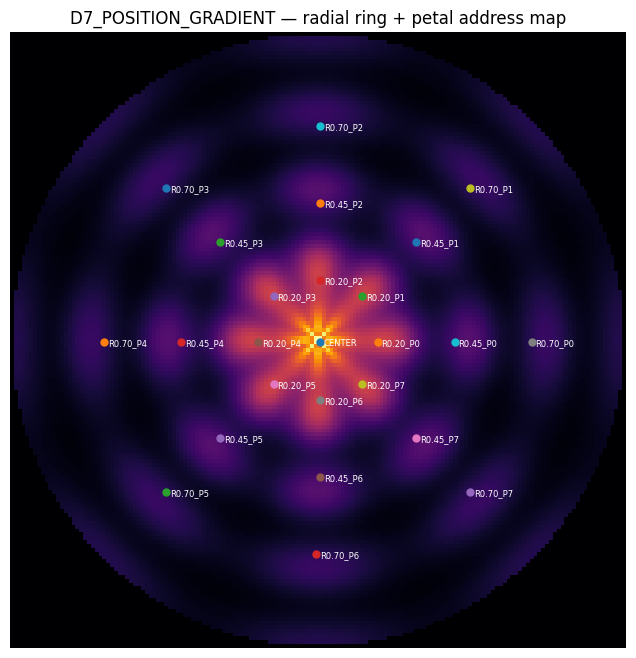

,STATE,X,Y,R_NORM,THETA_DEG,DEPTH,PETAL_INDEX,PETAL,ACTIVATION,LEVEL,ADDRESS,POINT
0,D7_POSITION_GRADIENT,80,80,0.00,0.0,D7_CENTER,0,D7_BINDU,1.000,HIGH,D7_CENTER + D7_BINDU,CENTER
1,D7_POSITION_GRADIENT,95,80,0.20,0.0,D7_RING_INNER,0,D7_PETAL_0,0.539,MID,D7_RING_INNER + D7_PETAL_0,R0.20_P0
2,D7_POSITION_GRADIENT,91,68,0.20,45.0,D7_RING_INNER,1,D7_PETAL_1,0.546,MID,D7_RING_INNER + D7_PETAL_1,R0.20_P1
3,D7_POSITION_GRADIENT,80,64,0.20,90.0,D7_RING_INNER,2,D7_PETAL_2,0.539,MID,D7_RING_INNER + D7_PETAL_2,R0.20_P2
4,D7_POSITION_GRADIENT,68,68,0.20,135.0,D7_RING_INNER,3,D7_PETAL_3,0.546,MID,D7_RING_INNER + D7_PETAL_3,R0.20_P3
5,D7_POSITION_GRADIENT,64,80,0.20,180.0,D7_RING_INNER,4,D7_PETAL_4,0.539,MID,D7_RING_INNER + D7_PETAL_4,R0.20_P4
6,D7_POSITION_GRADIENT,68,91,0.20,225.0,D7_RING_INNER,5,D7_PETAL_5,0.546,MID,D7_RING_INNER + D7_PETAL_5,R0.20_P5
7,D7_POSITION_GRADIENT,80,95,0.20,270.0,D7_RING_INNER,6,D7_PETAL_6,0.539,MID,D7_RING_INNER + D7_PETAL_6,R0.20_P6
8,D7_POSITION_GRADIENT,91,91,0.20,315.0,D7_RING_INNER,7,D7_PETAL_7,0.546,MID,D7_RING_INNER + D7_PETAL_7,R0.20_P7
9,D7_POSITION_GRADIENT,115,80,0.45,0.0,D7_RING_MID,0,D7_PETAL_0,0.209,LOW,D7_RING_MID + D7_PETAL_0,R0.45_P0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def generate_radial_morphogen_field(size=160, petals=8, rings=4):
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)

    X, Y = np.meshgrid(x, y)

    R = np.sqrt(X**2 + Y**2)
    Theta = np.arctan2(Y, X)

    mask = (R <= 1.0).astype(float)

    # Сильний центр / Bindu
    center = np.exp(-18 * R**2)

    # Радіальна хвиля: кільця від центру назовні
    radial_wave = 0.5 + 0.5 * np.cos(2 * np.pi * rings * R)

    # Пелюсткова симетрія: кутові сектори
    angular_wave = 0.5 + 0.5 * np.cos(petals * Theta)

    # Морфогенний спад від центру до краю
    envelope = np.exp(-1.25 * R)

    # Підсилюємо так, щоб кільця і пелюстки були видимі
    Z = (
        0.55 * center
        + 0.45 * envelope * (0.35 + 0.65 * radial_wave) * (0.35 + 0.65 * angular_wave)
    )

    Z = Z * mask
    Z = (Z - Z.min()) / (Z.max() - Z.min() + 1e-9)

    return Z, R, Theta


def get_field_address(Z, x, y, petals=8):
    h, w = Z.shape

    cx = (w - 1) / 2
    cy = (h - 1) / 2

    dx = x - cx
    dy = cy - y

    r = np.sqrt(dx**2 + dy**2)
    max_r = min(cx, cy)
    r_norm = r / max_r

    theta = np.arctan2(dy, dx)

    if theta < 0:
        theta += 2 * np.pi

    sector_width = 2 * np.pi / petals
    petal_index = int(((theta + sector_width / 2) % (2 * np.pi)) // sector_width)

    if r_norm < 0.08:
        depth = "D7_CENTER"
    elif r_norm < 0.28:
        depth = "D7_RING_INNER"
    elif r_norm < 0.52:
        depth = "D7_RING_MID"
    elif r_norm < 0.78:
        depth = "D7_RING_OUTER"
    elif r_norm <= 1.05:
        depth = "D7_RING_EDGE"
    else:
        depth = "D7_OUTSIDE"

    row = int(np.clip(round(y), 0, h - 1))
    col = int(np.clip(round(x), 0, w - 1))

    activation = float(Z[row, col])

    if activation > 0.55:
        level = "HIGH"
    elif activation > 0.25:
        level = "MID"
    elif activation > 0.08:
        level = "LOW"
    else:
        level = "EMPTY"

    if depth == "D7_CENTER":
        petal = "D7_BINDU"
    elif depth == "D7_OUTSIDE":
        petal = "D7_NO_PETAL"
    else:
        petal = f"D7_PETAL_{petal_index}"

    address = f"{depth} + {petal}"

    return {
        "STATE": "D7_POSITION_GRADIENT",
        "X": int(round(x)),
        "Y": int(round(y)),
        "R_NORM": round(float(r_norm), 3),
        "THETA_DEG": round(float(np.degrees(theta)), 1),
        "DEPTH": depth,
        "PETAL_INDEX": petal_index,
        "PETAL": petal,
        "ACTIVATION": round(activation, 3),
        "LEVEL": level,
        "ADDRESS": address,
    }


def sample_field_addresses(Z, petals=8):
    h, w = Z.shape

    cx = (w - 1) / 2
    cy = (h - 1) / 2
    max_r = min(cx, cy)

    samples = []

    samples.append(("CENTER", cx, cy))

    sector_width = 2 * np.pi / petals

    for r_norm in [0.20, 0.45, 0.70]:
        for p in range(petals):
            theta = p * sector_width

            x = cx + np.cos(theta) * r_norm * max_r
            y = cy - np.sin(theta) * r_norm * max_r

            samples.append((f"R{r_norm:.2f}_P{p}", x, y))

    rows = []

    for name, x, y in samples:
        addr = get_field_address(Z, x, y, petals=petals)
        addr["POINT"] = name
        rows.append(addr)

    return pd.DataFrame(rows)


petals = 8

Z, R, Theta = generate_radial_morphogen_field(
    size=160,
    petals=petals,
    rings=4
)

df = sample_field_addresses(Z, petals=petals)

plt.figure(figsize=(8, 8))
plt.imshow(Z, cmap="inferno")

for _, row in df.iterrows():
    x = row["X"]
    y = row["Y"]

    plt.scatter(x, y, s=25)
    plt.text(
        x + 1,
        y + 1,
        row["POINT"],
        fontsize=6,
        color="white"
    )

plt.title("D7_POSITION_GRADIENT — radial ring + petal address map")
plt.axis("off")
plt.show()

df